# Brachistochrone trajectories from the graded $\sigma^{x,y}_{\rm eff}$ expansion

Companion to `gkp_sigma_x_effective_expansion.ipynb` and `sigma_x_eff_expansion.tex`.
That notebook expanded the time-optimal generator for vacuum $\to$ GKP into a normal-ordered
ladder series graded by total degree $d=p+q=n+2k$. This one **propagates** the truncated
generators and asks what the dynamics look like as non-linear orders are added back in.

The generator, in the convention of `brachistochrone.py`
($\phi=\arg\langle\psi_i|\psi_f\rangle$, $H=\omega[\sin\phi\,\sigma^x_{\rm eff}+\cos\phi\,\sigma^y_{\rm eff}]$):

$$H_{\rm opt} \;=\; i\omega\,e^{-i\phi}R\,\mathcal N^{\Delta}_{\mu}
\sum_{n\ge1}\sum_{k\ge0}\frac{(-1)^k}{n!\,k!}\,S_n\,
\hat a^{\dagger\,n+k}\hat a^{k}\;+\;{\rm h.c.}$$

Since $\sin\phi+i\cos\phi = ie^{-i\phi}$, both effective Paulis collapse into one term plus its
adjoint, so a single complex coefficient $c_{nk}\propto(-1)^kS_n/(n!k!)$ carries everything.

### Three ways to truncate, and they are not equivalent

| scheme | index set | meaning | behaviour |
|---|---|---|---|
| `bare` | $k=0$, $n\le D$ | pure $n$-photon drive $\sum_n\lambda_n\hat a^{\dagger n}+{\rm h.c.}$ | does **not** converge |
| `photon` | $n\le D$, $k$ complete | exact vacuum projector, $n$ truncated | converges, stays rank 2 |
| `degree` | $n+2k\le D$ | the grading in the `.tex` | $\lVert H\rVert$ diverges |

### Headline results derived and verified below

1. **Parity selection rule.** $S_n=0$ for all odd $n$, for both logical states. Every odd-$d$
   block in `sigma_x_eff_expansion.tex` vanishes identically — half the printed expansion is zero,
   and the leading term is two-photon squeezing, *not* a displacement.
2. **The $k$-sum must be resummed analytically.** Summing the monomials explicitly bleeds digits
   and then collapses: at $\dim_{\rm F}=80$ it returns $\lVert H\rVert\sim10^{12}$ where the answer is
   exactly $1$.
3. **Closed-form fidelity.** For the `photon` scheme the peak achievable fidelity is exactly
   $$F_\star(D)=|s|^2+(1-|s|^2)\,w_D^2,\qquad
   1-F_\star(D)=\sum_{n>D}|\langle n|\tilde\mu_L\rangle|^2 ,$$
   i.e. **the infidelity of the degree-$D$ generator is the Fock tail weight of the target above
   level $D$.** No simulation needed; the simulation confirms it to $10^{-16}$.
4. **$\Delta E$ is well behaved even when $\lVert H\rVert$ is not.** The energy variance is conserved,
   scheme-independent, and equals $\omega R\mathcal N\sqrt{\sum_{n\le D}|S_n|^2/n!}\le\omega$, so
   truncation can only *slow* the evolution. Mandelstam–Tamm statements should be quoted from
   $\Delta E$, never from the spectral norm.
5. **$D_\star(\Delta)$.** The order needed for $F_\star=0.99$ runs from $D_\star=8$ at $4.4$ dB to
   $D_\star=28$ at $10.5$ dB, and equals the 99th-percentile Fock level in every case tested.

## 1. Setup

Pure NumPy/SciPy so this runs in the sandbox kernel (no JAX). The project imports are guarded and
used only for cross-checks; when `jaxquantum` is present, `utils.compute_wigner` and
`plotting.plot_wigner` are preferred over the local fallbacks in §10.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from math import pi, sqrt
from scipy.special import gammaln, eval_laguerre

np.set_printoptions(precision=5, suppress=True, linewidth=110)
trapz = getattr(np, "trapezoid", None) or np.trapz   # numpy >= 2.0 renamed trapz

try:
    from gkp_optimal_control.brachistochrone import quantum_brachistochrone_hamiltonian
    from gkp_optimal_control.states import gkp_states
    from gkp_optimal_control.utils import compute_wigner, to_qarray
    HAVE_PROJECT = True
except Exception as exc:          # ModuleNotFoundError, or JAX missing
    HAVE_PROJECT = False
    _PROJECT_EXC = exc

print("project modules:", "found" if HAVE_PROJECT else f"not found ({type(_PROJECT_EXC).__name__})")

# Publication-ish defaults. plotting.set_plot_style() additionally sets text.usetex=True,
# which needs a LaTeX install, so it is not called here.
plt.rcParams.update({"font.family": "serif", "font.size": 11, "axes.labelsize": 11,
                     "axes.titlesize": 12, "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.25, "legend.frameon": False})

# ---- working point -------------------------------------------------------
MU        = 0            # target logical state |mu_L>
ALPHA     = sqrt(pi / 2)      # square lattice: logical-Z primitive
BETA      = 1j * sqrt(pi / 2) # logical-X primitive
DELTA     = 0.30         # envelope width  (-10 log10 Delta^2 = 8.0 dB)
CUTOFF    = 4            # lattice-sum shells
DIM       = 80           # Fock truncation
OMEGA     = 1.0          # energy scale: ||H_exact||_2 = OMEGA

print(f"Delta = {DELTA}  ({-10 * np.log10(DELTA ** 2):.1f} dB),  "
      f"lattice cutoff = {CUTOFF},  dim_F = {DIM}")

project modules: found
Delta = 0.3  (10.5 dB),  lattice cutoff = 4,  dim_F = 80


## 2. Lattice moments and the target state

Everything about the target enters through the single family of lattice sums from notebook 1,

$$S^{(\mu)}_n=\sum_{j,l\in\mathbb Z}e^{-i\pi(2j+\mu)l/2}e^{-|\zeta_{2j+\mu,l}|^2/2}
\bigl(e^{-\Delta^2}\zeta_{2j+\mu,l}\bigr)^{n},
\qquad \langle n|\tilde\mu_L\rangle=\mathcal N^{\Delta}_{\mu}S_n/\sqrt{n!},$$

and the derived scalars $s=\langle0|\tilde\mu_L\rangle$, $\phi=\arg s$, $R=(1-|s|^2)^{-1/2}$,
$\theta_B=\arccos|s|$, $T_\star=\theta_B/\omega$.

**Conditioning warning, carried over from notebook 1 §8.** Individual lattice terms have Fock
support out to $|\zeta^\Delta_{m,l}|^2$, which at `CUTOFF=4` reaches $\approx84$ — far above the
assembled state's $\bar n\approx2.4$. The state is small because of cancellation *between* large
terms, so `DIM` must cover the largest surviving $|\zeta^\Delta|^2$, not $\bar n$. The convergence
table below checks both knobs.

In [3]:
def lattice_moments(nmax, mu, alpha_v, beta_v, delta_v, cutoff):
    """S_n^{(mu)} for n = 0..nmax by direct lattice summation (notes' convention)."""
    S = np.zeros(nmax + 1, complex)
    powers = np.arange(nmax + 1)
    for jj in range(-cutoff, cutoff + 1):
        for ll in range(-cutoff, cutoff + 1):
            m = 2 * jj + mu
            z = m * alpha_v + ll * beta_v
            weight = np.exp(-1j * pi * m * ll / 2) * np.exp(-abs(z) ** 2 / 2)
            zd = np.exp(-delta_v ** 2) * z
            if zd == 0:
                pw = np.zeros(nmax + 1, complex)
                pw[0] = 1.0
            else:                      # log-space to survive |zeta^Delta|^n at large n
                pw = np.exp(powers * np.log(abs(zd)) + 1j * powers * np.angle(zd))
            S += weight * pw
    return S


def target_from_moments(dim, S):
    """(normalized |mu_L> in the Fock basis, N^Delta_mu)."""
    v = S[:dim] / np.exp(0.5 * gammaln(np.arange(dim) + 1.0))
    nrm = np.linalg.norm(v)
    return v / nrm, 1.0 / nrm


def reference_scalars(psi, omega=OMEGA):
    s = psi[0]
    a = min(abs(s), 1.0)
    return dict(s=s, phi=float(np.angle(s)), R=1.0 / sqrt(1.0 - a ** 2),
                theta_B=float(np.arccos(a)), T_star=float(np.arccos(a)) / omega)


S_MOM = lattice_moments(DIM - 1, MU, ALPHA, BETA, DELTA, CUTOFF)
PSI_F, NRM = target_from_moments(DIM, S_MOM)
REF = reference_scalars(PSI_F)
T_STAR = REF["T_star"]

nbar = float(np.sum(np.arange(DIM) * np.abs(PSI_F) ** 2))
print(f"|s| = {abs(REF['s']):.6f}   phi = {REF['phi']:+.3e}   R = {REF['R']:.6f}")
print(f"theta_B = {REF['theta_B']:.6f}   T* = {T_STAR:.6f}   N^Delta = {NRM:.6e}")
print(f"nbar = {nbar:.4f}   Fock tail (top 5 levels) = {np.abs(PSI_F[-5:]).max():.2e}")

|s| = 0.576748   phi = +4.957e-35   R = 1.224107
theta_B = 0.956054   T* = 0.956054   N^Delta = 2.862318e-01
nbar = 4.9941   Fock tail (top 5 levels) = 4.12e-04


In [4]:
# Joint convergence in the two independent knobs: lattice shells and Fock cutoff.
print("cutoff  dim   |s|        nbar    |psi_top5|   overlap vs next")
prev = None
for cut in (2, 3, 4, 5):
    S_c = lattice_moments(DIM - 1, MU, ALPHA, BETA, DELTA, cut)
    psi_c, _ = target_from_moments(DIM, S_c)
    ov = abs(psi_c.conj() @ prev) if prev is not None else float("nan")
    print(f"{cut:6d} {DIM:4d}   {abs(psi_c[0]):.6f}  {np.sum(np.arange(DIM) * abs(psi_c) ** 2):6.3f}"
          f"   {np.abs(psi_c[-5:]).max():.2e}     {ov:.10f}")
    prev = psi_c
print()
print("  dim   |s|        nbar    |psi_top5|")
for dim_try in (30, 50, 80, 110):
    S_d = lattice_moments(dim_try - 1, MU, ALPHA, BETA, DELTA, CUTOFF)
    psi_d, _ = target_from_moments(dim_try, S_d)
    print(f"{dim_try:5d}   {abs(psi_d[0]):.6f}  {np.sum(np.arange(dim_try) * abs(psi_d) ** 2):6.3f}"
          f"   {np.abs(psi_d[-5:]).max():.2e}")

cutoff  dim   |s|        nbar    |psi_top5|   overlap vs next
     2   80   0.609384   4.077   2.64e-09     nan
     3   80   0.582020   4.738   2.48e-04     0.9861973174
     4   80   0.576748   4.994   4.12e-04     0.9978707570
     5   80   0.576091   5.048   5.70e-04     0.9998005658

  dim   |s|        nbar    |psi_top5|
   30   0.577263   4.939   1.02e-01
   50   0.576764   4.991   5.13e-03
   80   0.576748   4.994   4.12e-04
  110   0.576748   4.994   4.98e-05


In [5]:
# Cross-check against states.py (NumPy mirror + the convention map from notebook 1 sec 8).
def _coherent(dim, z):
    if z == 0:
        v = np.zeros(dim, complex); v[0] = 1.0; return v
    p = np.arange(dim)
    return np.exp(-abs(z) ** 2 / 2 + p * np.log(abs(z)) - 0.5 * gammaln(p + 1.0)) \
        * np.exp(1j * p * np.angle(z))


def gkp_statespy_mirror(dim, mu, alpha_v, beta_v, delta_v, cutoff):
    """NumPy mirror of states.py::gkp_states."""
    env = 0.5 * (1.0 - np.exp(-2 * delta_v ** 2))
    tot = np.zeros(dim, complex)
    for jj in range(-cutoff, cutoff + 1):
        for ll in range(-cutoff, cutoff + 1):
            z = (2 * jj + mu) * alpha_v + ll * beta_v
            tot += (np.exp(-1j * pi * (jj + mu / 2) * ll)
                    * np.exp(-env * abs(z) ** 2) * _coherent(dim, z))
    return tot / np.linalg.norm(tot)


def delta_eff(delta_v):
    """Notes' Delta -> states.py Delta. Requires Delta < sqrt(ln2/2) ~ 0.589."""
    return np.sqrt(-0.5 * np.log(2 - np.exp(2 * delta_v ** 2)))


mapped = gkp_statespy_mirror(DIM, MU, ALPHA * np.exp(-DELTA ** 2),
                             BETA * np.exp(-DELTA ** 2), delta_eff(DELTA), CUTOFF)
naive = gkp_statespy_mirror(DIM, MU, ALPHA, BETA, DELTA, CUTOFF)
print(f"|<moments | states.py mapped>| = {abs(PSI_F.conj() @ mapped):.12f}")
print(f"|<moments | states.py naive >| = {abs(PSI_F.conj() @ naive):.12f}   <- wrong convention")

|<moments | states.py mapped>| = 1.000000000000
|<moments | states.py naive >| = 0.997386518106   <- wrong convention


## 3. A parity selection rule kills half the expansion

Both $|0\rangle$ and the square-lattice codestates $|\tilde\mu_L\rangle$ are eigenstates of photon
parity $(-1)^{\hat n}$ with eigenvalue $+1$: the lattice $\{\zeta_{m,l}\}$ is symmetric under
$\zeta\to-\zeta$ (send $m\to-m,\ l\to-l$, which preserves $m\equiv\mu$ and leaves $e^{-i\pi ml/2}$
and $|\zeta|$ unchanged), so odd powers cancel term by term:

$$S_n = 0 \quad\text{for all odd } n \quad\Longrightarrow\quad
\langle n|\tilde\mu_L\rangle = 0 \ \text{ for odd } n .$$

Since $d=n+2k$, odd $d$ means odd $n$. **Every odd-$d$ block in `sigma_x_eff_expansion.tex`
is identically zero for a square lattice**, including the $d=1$ block — so the leading term of the
time-optimal generator is the $d=2$ two-photon (squeezing-type) term $S_2\hat a^{\dagger2}/2+{\rm h.c.}$,
not a displacement. The $d=1$ remark in notebook 1 §6 needs that amendment.

The generator therefore connects $|0\rangle$ only to even Fock levels, and the trajectory stays in
the even-parity sector for all time — a free unit test on any propagator.

In [6]:
print("max |S_n| / sqrt(n!)   (i.e. max unnormalized Fock amplitude)")
for mu_try in (0, 1):
    S_t = lattice_moments(DIM - 1, mu_try, ALPHA, BETA, DELTA, CUTOFF)
    psi_t, _ = target_from_moments(DIM, S_t)
    print(f"  mu={mu_try}:  odd n -> {np.abs(psi_t[1::2]).max():.3e}      "
          f"even n -> {np.abs(psi_t[0::2]).max():.3e}")

print("\nwhich .tex blocks survive, d = 1..12:")
for d in range(1, 13):
    live = [n for n in range(1, d + 1) if (d - n) % 2 == 0 and abs(S_MOM[n]) > 1e-8 * abs(S_MOM[2])]
    print(f"  d={d:2d}: " + ("vanishes (all S_n with n odd)" if d % 2 else f"survives, n in {live}"))

print(f"\n|S_1|/|S_2| = {abs(S_MOM[1]) / abs(S_MOM[2]):.3e}   "
      f"-> no displacement term in H_opt")

max |S_n| / sqrt(n!)   (i.e. max unnormalized Fock amplitude)
  mu=0:  odd n -> 3.622e-16      even n -> 5.767e-01
  mu=1:  odd n -> 4.747e-07      even n -> 7.457e-01

which .tex blocks survive, d = 1..12:
  d= 1: vanishes (all S_n with n odd)
  d= 2: survives, n in [2]
  d= 3: vanishes (all S_n with n odd)
  d= 4: survives, n in [2, 4]
  d= 5: vanishes (all S_n with n odd)
  d= 6: survives, n in [2, 4, 6]
  d= 7: vanishes (all S_n with n odd)
  d= 8: survives, n in [2, 4, 6, 8]
  d= 9: vanishes (all S_n with n odd)
  d=10: survives, n in [2, 4, 6, 8, 10]
  d=11: vanishes (all S_n with n odd)
  d=12: survives, n in [2, 4, 6, 8, 10, 12]

|S_1|/|S_2| = 5.674e-17   -> no displacement term in H_opt


## 4. The $k$-sum has to be resummed analytically

Notebook 1 §7 showed that the $k$-sum collapses on each band:

$$\chi(q,K)\;\equiv\;\sum_{k=0}^{\min(K,q)}(-1)^k\binom{q}{k}
=\begin{cases}1,& q=0,\\ 0,& 1\le q\le K,\\ (-1)^K\binom{q-1}{K},& q>K,\end{cases}$$

so the whole $(n,\,k\le K)$ block is a single band with matrix elements

$$\Bigl[\textstyle\sum_{k\le K}\frac{(-1)^k}{k!}\hat a^{\dagger n+k}\hat a^{k}\Bigr]_{q+n,\,q}
=\sqrt{\frac{(q+n)!}{q!}}\;\chi(q,K).$$

That is not just tidier — it is the difference between a usable and a useless notebook. Summing the
monomials explicitly asks floating point to cancel terms of size $\sqrt{q!(q+n)!}/(q-k)!$ against
each other down to zero, and $\binom{q}{q/2}$ sets the price: about 8 digits at $q=25$, all 16 by
$q\approx50$. The cell below builds $\lVert H\rVert$ both ways. The exact answer is $1$; the
explicit sum is exact at $\dim_{\rm F}=30$, has lost six digits by $40$, and past $50$ there is
nothing left of it at all.

In [7]:
def chi(q, K):
    """Closed-form k-sum; q may be an array."""
    q = np.atleast_1d(np.asarray(q))
    out = np.zeros(q.shape, float)
    out[q == 0] = 1.0
    hi = q > K
    if np.any(hi):
        qq = q[hi].astype(float)
        out[hi] = (-1.0) ** K * np.exp(gammaln(qq) - gammaln(K + 1.0) - gammaln(qq - K))
    return out


def band(dim, n, K):
    """sum_{k<=K} (-1)^k/k! adag^(n+k) a^k, cancellation-free."""
    M = np.zeros((dim, dim))
    q = np.arange(0, max(dim - n, 0))
    if q.size:
        M[q + n, q] = np.exp(0.5 * (gammaln(q + n + 1.0) - gammaln(q + 1.0))) * chi(q, K)
    return M


def monomial(dim, n, k):
    """adag^(n+k) a^k, for cross-checking `band` where cancellation is still harmless."""
    p, q = n + k, k
    M = np.zeros((dim, dim))
    c = np.arange(q, dim)
    r = c - q + p
    ok = r < dim
    c, r = c[ok], r[ok]
    if c.size:
        M[r, c] = np.exp(0.5 * (gammaln(c + 1.0) + gammaln(r + 1.0)) - gammaln(c - q + 1.0))
    return M


def band_explicit(dim, n, K):
    return sum((-1.0) ** k * np.exp(-gammaln(k + 1.0)) * monomial(dim, n, k)
               for k in range(K + 1))


worst = 0.0
for dim_t in (8, 14, 20):
    for n in range(1, 5):
        for K in range(0, 8):
            A, B = band(dim_t, n, K), band_explicit(dim_t, n, K)
            worst = max(worst, np.abs(A - B).max() / max(1.0, np.abs(B).max()))
print(f"band vs explicit monomial sum, dim <= 20: max relative deviation = {worst:.2e}")

band vs explicit monomial sum, dim <= 20: max relative deviation = 1.88e-14


In [8]:
# The same quantity, two ways, as a function of Fock cutoff. Exact answer: 1.0
print(" dim   ||H||_2 analytic   ||H||_2 explicit-k   |explicit - 1|   sigma_3/sigma_1")
for dim_t in (20, 30, 40, 50, 60, DIM):
    S_t = lattice_moments(dim_t - 1, MU, ALPHA, BETA, DELTA, CUTOFF)
    psi_t, nrm_t = target_from_moments(dim_t, S_t)
    ref_t = reference_scalars(psi_t)
    pref = 1j * OMEGA * np.exp(-1j * ref_t["phi"]) * ref_t["R"] * nrm_t
    Xa = sum((S_t[n] / np.exp(gammaln(n + 1.0))) * band(dim_t, n, dim_t - 1)
             for n in range(1, dim_t))
    Xe = sum((S_t[n] / np.exp(gammaln(n + 1.0))) * band_explicit(dim_t, n, dim_t - 1)
             for n in range(1, dim_t))
    Ha, He = pref * Xa, pref * Xe
    Ha, He = Ha + Ha.conj().T, He + He.conj().T
    sv = np.linalg.svd(Ha, compute_uv=False)
    na, ne = np.linalg.norm(Ha, 2), np.linalg.norm(He, 2)
    print(f"{dim_t:4d}   {na:17.12f}   {ne:18.6e}   {abs(ne - 1.0):14.2e}   {sv[2] / sv[0]:.2e}")
print("\n=> the analytic band is exact to machine precision and manifestly rank 2;")
print("   the explicit k-sum bleeds digits and then collapses between dim_F = 40 and 50.")

 dim   ||H||_2 analytic   ||H||_2 explicit-k   |explicit - 1|   sigma_3/sigma_1
  20      1.000000000000         1.000000e+00         2.22e-16   7.68e-17
  30      1.000000000000         1.000000e+00         1.22e-13   1.19e-16
  40      1.000000000000         1.000000e+00         7.61e-08   1.47e-16
  50      1.000000000000         3.816289e+01         3.72e+01   1.06e-16
  60      1.000000000000         7.454751e+04         7.45e+04   1.09e-16
  80      1.000000000000         9.649164e+11         9.65e+11   1.01e-16

=> the analytic band is exact to machine precision and manifestly rank 2;
   the explicit k-sum bleeds digits and then collapses between dim_F = 40 and 50.


## 5. The three grading schemes

Each scheme is a choice of which $(n,K_n)$ bands to keep:

* **`bare`** — $K_n=0$: only the $k=0$ monomials survive, giving a pure multi-photon drive
  $H=\sum_{n\le D}(\lambda_n\hat a^{\dagger n}+\lambda_n^*\hat a^n)$ with $\lambda_n\propto S_n/n!$.
  The most hardware-legible reading of "up to $n$-photon processes", and the one that fails.
* **`photon`** — $K_n=\dim_{\rm F}-1$: the vacuum projector is represented *exactly* (§4: $\chi$
  vanishes on $1\le q\le K$), so $H_D=\omega\,w_D\bigl(ie^{-i\phi}|\hat v_D\rangle\langle0|+{\rm h.c.}\bigr)$
  stays rank 2, with $|v_D\rangle=P_D|\psi_f^\perp\rangle$.
* **`degree`** — $K_n=\lfloor(D-n)/2\rfloor$: the literal $n+2k\le D$ grading of the `.tex`.

The unit test that matters: at $D=\dim_{\rm F}-1$ the `photon` scheme must reproduce the rank-2
$H$ built directly as an outer product, with $\lVert H\rVert_2=\omega$ exactly.

In [20]:
SCHEMES = ("bare", "photon", "degree")


def scheme_bands(D, dim, scheme):
    """[(n, K_n)] kept at grading level D."""
    n_hi = min(D, dim - 1)
    if scheme == "bare":
        return [(n, 0) for n in range(1, n_hi + 1)]
    if scheme == "photon":
        return [(n, dim - 1) for n in range(1, n_hi + 1)]
    if scheme == "degree":
        return [(n, (D - n) // 2) for n in range(1, n_hi + 1)]
    raise ValueError(f"unknown scheme {scheme!r}")


def graded_H(S, nrm, ref, dim, D, scheme, omega=OMEGA):
    """Truncated H_opt = i w e^{-i phi} R N sum (-1)^k S_n/(n! k!) adag^{n+k} a^k + h.c."""
    pref = 1j * omega * np.exp(-1j * ref["phi"]) * ref["R"] * nrm
    X = np.zeros((dim, dim), complex)
    for n, K in scheme_bands(D, dim, scheme):
        X += (S[n] / np.exp(gammaln(n + 1.0))) * band(dim, n, K)
    X = pref * X
    return X + X.conj().T


def exact_H(psi, dim, omega=OMEGA):
    """Rank-2 H_opt straight from the outer product (the brachistochrone.py construction)."""
    ref = reference_scalars(psi, omega)
    e0 = np.zeros(dim); e0[0] = 1.0
    perp = (psi - ref["s"] * e0) * ref["R"]
    X = 1j * omega * np.exp(-1j * ref["phi"]) * np.outer(perp, e0)
    return X + X.conj().T, perp


H_EXACT, PSI_PERP = exact_H(PSI_F, DIM)
H_full = graded_H(S_MOM, NRM, REF, DIM, DIM - 1, "photon")
sv = np.linalg.svd(H_EXACT, compute_uv=False)
print(f"||H_photon(D=dim-1) - H_exact||_max = {np.abs(H_full - H_EXACT).max():.3e}")
print(f"||H_exact||_2 = {np.linalg.norm(H_EXACT, 2):.14f}   (should be OMEGA = {OMEGA})")
print(f"sigma_3/sigma_1 = {sv[2] / sv[0]:.2e}   <psi_perp|0> = {PSI_PERP[0]:.2e}")
print(f"Hermiticity: ||H - H^dag||_max = {np.abs(H_EXACT - H_EXACT.conj().T).max():.2e}")

h_proj, t_proj = quantum_brachistochrone_hamiltonian(
    jnp.asarray(np.eye(DIM, 1).ravel(), dtype=complex), jnp.asarray(PSI_F), OMEGA)
H_proj = np.asarray(getattr(h_proj, "data", h_proj))   # raw layer returns a bare array

||H_photon(D=dim-1) - H_exact||_max = 1.110e-16
||H_exact||_2 = 1.00000000000000   (should be OMEGA = 1.0)
sigma_3/sigma_1 = 9.93e-17   <psi_perp|0> = 0.00e+00+0.00e+00j
Hermiticity: ||H - H^dag||_max = 0.00e+00


## 6. The `photon` scheme has a closed-form trajectory

Write $w_D\equiv\lVert P_D|\psi_f^\perp\rangle\rVert
= R\,\mathcal N^{\Delta}_{\mu}\bigl(\sum_{n=1}^{D}|S_n|^2/n!\bigr)^{1/2}$. Then
$H_D=\omega w_D\,(\hat n_\phi\!\cdot\!\vec\sigma)$ on ${\rm span}\{|0\rangle,|\hat v_D\rangle\}$, so

$$|\psi(t)\rangle=\cos(\omega w_D t)\,|0\rangle+\sin(\omega w_D t)\,e^{-i\phi}|\hat v_D\rangle .$$

Using $\langle\psi_f^\perp|\hat v_D\rangle=w_D$ and $|\psi_f\rangle=s|0\rangle+\sqrt{1-|s|^2}\,|\psi_f^\perp\rangle$,

$$F(t)=\bigl(|s|\cos\omega w_Dt+\sqrt{1-|s|^2}\,w_D\sin\omega w_Dt\bigr)^2
\;\Longrightarrow\;
\boxed{F_\star(D)=|s|^2+(1-|s|^2)w_D^2}$$

attained at $\omega w_D t_\star=\arctan\!\bigl(\sqrt{1-|s|^2}\,w_D/|s|\bigr)$. Because
$R^2(1-|s|^2)=1$ and $\mathcal N^2\sum_{n\ge0}|S_n|^2/n!=1$, the infidelity telescopes to

$$1-F_\star(D)=\mathcal N^2\!\!\sum_{n>D}\frac{|S_n|^2}{n!}=\sum_{n>D}\bigl|\langle n|\tilde\mu_L\rangle\bigr|^2 .$$

So the question "how many non-linear orders do I need" has the same answer as "how much Fock tail
does my target have" — and $w_D\to1$ gives $t_\star\to T_\star$, recovering the geodesic.

In [21]:
def w_of_D(S, nrm, ref, D, omega=OMEGA):
    """w_D = ||P_D |psi_perp>|| = Delta E(D) / omega.  Scheme independent."""
    n = np.arange(1, D + 1)
    return ref["R"] * nrm * sqrt(float(np.sum(np.abs(S[1:D + 1]) ** 2 / np.exp(gammaln(n + 1.0)))))


def peak_fidelity_analytic(S, nrm, ref, D):
    s2 = abs(ref["s"]) ** 2
    w = w_of_D(S, nrm, ref, D)
    F = s2 + (1 - s2) * w ** 2
    t = np.arctan2(sqrt(max(1 - s2, 0.0)) * w, sqrt(s2)) / (w * OMEGA) if w > 0 else 0.0
    return F, t, w


def trajectory(H, times, dim):
    """|psi(t)> from vacuum under constant H, by one eigendecomposition."""
    w, V = np.linalg.eigh(H)
    e0 = np.zeros(dim, complex); e0[0] = 1.0
    c0 = V.conj().T @ e0
    return (np.exp(-1j * np.outer(times, w)) * c0[None, :]) @ V.T


def diagnostics(H, psi_target, times, dim):
    psis = trajectory(H, times, dim)
    e0 = np.zeros(dim, complex); e0[0] = 1.0
    s = psi_target[0]
    perp = (psi_target - s * e0) / sqrt(1.0 - min(abs(s), 1.0) ** 2)
    inpl = np.abs(psis @ e0.conj()) ** 2 + np.abs(psis @ perp.conj()) ** 2
    Hpsi = psis @ H.T                       # BLAS; einsum here is ~100x slower
    eH = np.real(np.sum(psis.conj() * Hpsi, axis=1))
    eH2 = np.real(np.sum(np.abs(Hpsi) ** 2, axis=1))
    return dict(psis=psis,
                fid=np.abs(psis @ psi_target.conj()) ** 2,
                leak=1.0 - inpl,
                nbar=np.real((np.abs(psis) ** 2) @ np.arange(dim)),
                odd=np.sum(np.abs(psis[:, 1::2]) ** 2, axis=1),
                dE=np.sqrt(np.maximum(eH2 - eH ** 2, 0.0)))


def peak_fidelity_numeric(H, psi_target, dim, t_scale=None, t_hi=2.0, rounds=7, npts=321):
    """Peak fidelity and the time it occurs, by nested grid refinement."""
    t_scale = T_STAR if t_scale is None else t_scale
    lo, hi = 0.0, t_hi
    for _ in range(rounds):
        tt = np.linspace(lo * t_scale, hi * t_scale, npts)
        f = diagnostics(H, psi_target, tt, dim)["fid"]
        i = int(f.argmax())
        lo, hi = tt[max(i - 1, 0)] / t_scale, tt[min(i + 1, npts - 1)] / t_scale
    return float(f[i]), float(tt[i])


print("  D |  F* numeric     F* analytic    |diff|    Fock tail>D    t*/T_star  (num / an)")
for D in (2, 4, 6, 8, 12, 16, 20, 30, 50, DIM - 1):
    H = graded_H(S_MOM, NRM, REF, DIM, D, "photon")
    Fn, tn = peak_fidelity_numeric(H, PSI_F, DIM)
    Fa, ta, _ = peak_fidelity_analytic(S_MOM, NRM, REF, D)
    tail = float(np.sum(np.abs(PSI_F[D + 1:]) ** 2))
    print(f"{D:3d} |  {Fn:.12f}  {Fa:.12f}  {abs(Fn - Fa):.1e}   {tail:.4e}    "
          f"{tn / T_STAR:.6f} / {ta / T_STAR:.6f}")
print(f"\n1 - F*(D) vs Fock tail above D: max abs deviation = "
      f"{max(abs((1 - peak_fidelity_analytic(S_MOM, NRM, REF, D)[0]) - float(np.sum(np.abs(PSI_F[D + 1:]) ** 2))) for D in range(2, 60, 2)):.2e}")

  D |  F* numeric     F* analytic    |diff|    Fock tail>D    t*/T_star  (num / an)
  2 |  0.427986315142  0.427986315142  5.6e-17   5.7201e-01    1.360241 / 1.360241
  4 |  0.582727506409  0.582727506409  1.1e-16   4.1727e-01    1.220532 / 1.220532
  6 |  0.609341663748  0.609341663748  1.1e-16   3.9066e-01    1.201134 / 1.201134
  8 |  0.906524351076  0.906524351076  0.0e+00   9.3476e-02    1.037797 / 1.037797
 12 |  0.918982421750  0.918982421750  1.1e-16   8.1018e-02    1.032479 / 1.032479
 16 |  0.974607423783  0.974607423783  3.3e-16   2.5393e-02    1.009808 / 1.009808
 20 |  0.978562059362  0.978562059362  2.2e-16   2.1438e-02    1.008259 / 1.008259
 30 |  0.998689584325  0.998689584325  4.4e-16   1.3104e-03    1.000498 / 1.000498
 50 |  0.999948461795  0.999948461795  1.1e-16   5.1538e-05    1.000020 / 1.000020
 79 |  1.000000000000  1.000000000000  4.4e-16   0.0000e+00    1.000000 / 1.000000

1 - F*(D) vs Fock tail above D: max abs deviation = 2.27e-16


## 7. Trajectories with increasing non-linear order

Because $H_{\rm opt}$ is time-*independent*, no ODE solver is needed anywhere: one `eigh` gives
$U(t)=Ve^{-i\Lambda t}V^\dagger$ at every time at once. The panels below are the `photon` scheme —
the only one that converges — against the exact geodesic.

Watch three things: the fidelity envelope rising to 1, the out-of-plane leakage
$1-|\langle0|\psi\rangle|^2-|\langle\psi_f^\perp|\psi\rangle|^2$ falling to 0 (it is *not* zero at
finite $D$, even though $H_D$ is rank 2 — the plane it preserves is the wrong one), and $\bar n(t)$
approaching the target's $\bar n$.

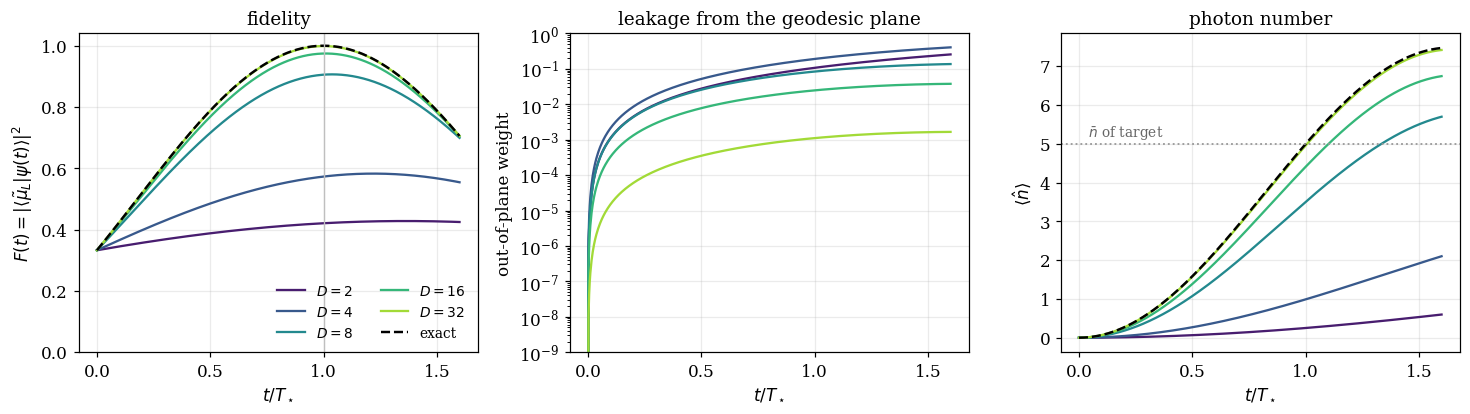

parity conservation (odd-Fock weight) along every trajectory:
  exact: 6.39e-31   D=2: 1.9e-33  D=4: 7.5e-32  D=8: 6.2e-32  D=16: 4.2e-31  D=32: 6.2e-31


In [11]:
D_LIST = [2, 4, 8, 16, 32]
times = np.linspace(0, 1.6 * T_STAR, 601)

runs = {D: diagnostics(graded_H(S_MOM, NRM, REF, DIM, D, "photon"), PSI_F, times, DIM)
        for D in D_LIST}
run_ex = diagnostics(H_EXACT, PSI_F, times, DIM)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.9))
colors = plt.cm.viridis(np.linspace(0.08, 0.86, len(D_LIST)))

for (D, c) in zip(D_LIST, colors):
    axes[0].plot(times / T_STAR, runs[D]["fid"], color=c, lw=1.5, label=f"$D={D}$")
    axes[1].semilogy(times / T_STAR, np.maximum(runs[D]["leak"], 1e-18), color=c, lw=1.5)
    axes[2].plot(times / T_STAR, runs[D]["nbar"], color=c, lw=1.5)

axes[0].plot(times / T_STAR, run_ex["fid"], "k--", lw=1.6, label="exact")
axes[2].plot(times / T_STAR, run_ex["nbar"], "k--", lw=1.6)
axes[2].axhline(nbar, color="0.6", ls=":", lw=1.2)
axes[2].text(0.04, nbar * 1.04, r"$\bar n$ of target", fontsize=9, color="0.4")

axes[0].axvline(1.0, color="0.75", lw=0.9)
axes[0].set(xlabel=r"$t/T_\star$", ylabel=r"$F(t)=|\langle\tilde\mu_L|\psi(t)\rangle|^2$",
            title="fidelity", ylim=(0, 1.04))
axes[0].legend(fontsize=9, ncol=2, loc="lower right")
axes[1].set(xlabel=r"$t/T_\star$", ylabel="out-of-plane weight",
            title="leakage from the geodesic plane", ylim=(1e-9, 1.0))
axes[2].set(xlabel=r"$t/T_\star$", ylabel=r"$\langle \hat n\rangle$", title="photon number")
fig.tight_layout()
plt.show()

print("parity conservation (odd-Fock weight) along every trajectory:")
print("  exact:", f"{run_ex['odd'].max():.2e}", "  " +
      "  ".join(f"D={D}: {runs[D]['odd'].max():.1e}" for D in D_LIST))

## 8. Why the other two schemes fail

The `bare` and `degree` schemes both truncate $k$, and §4's $\chi(q,K)$ says exactly what that
leaves behind: spurious matrix elements at $q>K$ of size
$\sqrt{(q+n)!/q!}\,\binom{q-1}{K}$, which grow super-factorially in $q$. Those columns are never
populated by the *exact* dynamics, but a truncated generator is no longer rank 2, so the
trajectory finds them immediately.

The table separates the two failure modes: the vacuum column ($q=0$) is correct in **all three**
schemes at the same $D$ — $\chi(0,K)=1$ always — so $\Delta E$ is identical across schemes. What
differs is everything off that column.

In [12]:
# Above this much spurious phase per T*, eigh itself is no longer trustworthy and the
# "dynamics" are numerical noise rather than physics.
RESOLVE_LIMIT = 1e10

rows = []
for scheme in SCHEMES:
    for D in (2, 4, 8, 16, 32):
        H = graded_H(S_MOM, NRM, REF, DIM, D, scheme)
        nrm2 = float(np.linalg.norm(H, 2))
        sv = np.linalg.svd(H, compute_uv=False)
        phase = nrm2 * T_STAR
        if phase < RESOLVE_LIMIT:
            F_pk, _ = peak_fidelity_numeric(H, PSI_F, DIM, t_hi=1.6)
            d = diagnostics(H, PSI_F, np.linspace(0, 1.6 * T_STAR, 601), DIM)
            leak, dE = float(d["leak"].max()), float(d["dE"].mean())
        else:
            F_pk, leak, dE = float("nan"), float("nan"), float("nan")
        rows.append((scheme, D, nrm2, sv[2] / sv[0], phase, F_pk, leak, dE,
                     w_of_D(S_MOM, NRM, REF, D)))

print(f"{'scheme':7s} {'D':>3s} {'||H||_2':>10s} {'sig3/sig1':>10s} {'||H||T*':>9s} "
      f"{'F_peak':>9s} {'leak_max':>9s} {'dE num':>9s} {'dE an':>9s}")
for r in rows:
    tail = "  (unresolvable)" if np.isnan(r[5]) else ""
    fpk = "      ---" if np.isnan(r[5]) else f"{r[5]:9.6f}"
    lk = "      ---" if np.isnan(r[6]) else f"{r[6]:9.2e}"
    de = "      ---" if np.isnan(r[7]) else f"{r[7]:9.6f}"
    print(f"{r[0]:7s} {r[1]:3d} {r[2]:10.3e} {r[3]:10.2e} {r[4]:9.2e} "
          f"{fpk} {lk} {de} {r[8]:9.6f}{tail}")
print("\nRead the last two columns first: dE(num) == dE(an) wherever the dynamics are")
print("resolvable, because chi(0,K)=1 makes the vacuum column scheme-independent.")
print("Everything that differs between schemes lives off that column. Note also that")
print("`bare` beating `photon` at D=2 is coincidence, not convergence -- it degrades after.")

scheme    D    ||H||_2  sig3/sig1   ||H||T*    F_peak  leak_max    dE num     dE an
bare      2  3.692e+01   9.86e-01  3.53e+01  0.557887  1.67e-01  0.377986  0.377986
bare      4  9.092e+02   9.73e-01  8.69e+02  0.508216  1.57e-01  0.612163  0.612163
bare      8  1.305e+05   9.46e-01  1.25e+05  0.415015  1.90e-01  0.927326  0.927326
bare     16  3.677e+07   8.93e-01  3.52e+07  0.432643  8.34e-02  0.980791  0.980791
bare     32  6.293e+09   8.00e-01  6.02e+09  0.479406  3.03e-01  0.999167  0.999167
photon    2  3.780e-01   1.18e-32  3.61e-01  0.427986  2.56e-01  0.377986  0.377986
photon    4  6.122e-01   7.42e-17  5.85e-01  0.582728  4.06e-01  0.612163  0.612163
photon    8  9.273e-01   6.48e-17  8.87e-01  0.906524  1.37e-01  0.927326  0.927326
photon   16  9.808e-01   9.32e-17  9.38e-01  0.974607  3.79e-02  0.980791  0.980791
photon   32  9.992e-01   8.55e-17  9.55e-01  0.998889  1.66e-03  0.999167  0.999167
degree    2  3.692e+01   9.86e-01  3.53e+01  0.557887  1.67e-01  0.377986  0

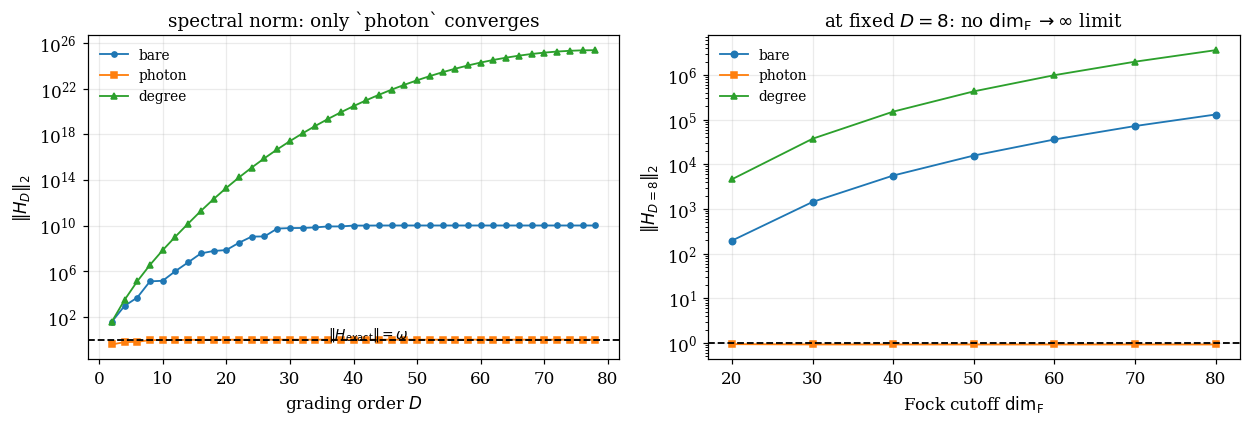

In [13]:
Ds = np.arange(2, DIM, 2)
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))

for scheme, mk in zip(SCHEMES, ("o", "s", "^")):
    nn = [np.linalg.norm(graded_H(S_MOM, NRM, REF, DIM, int(D), scheme), 2) for D in Ds]
    axes[0].semilogy(Ds, nn, mk + "-", ms=3.4, lw=1.2, label=scheme)
axes[0].axhline(OMEGA, color="k", ls="--", lw=1.2)
axes[0].text(DIM * 0.45, OMEGA * 1.6, r"$\|H_{\rm exact}\|=\omega$", fontsize=9)
axes[0].set(xlabel="grading order $D$", ylabel=r"$\|H_D\|_2$",
            title=r"spectral norm: only `photon` converges")
axes[0].legend(fontsize=9)

# Is the `degree` divergence a convergent limit in disguise? Vary the Fock cutoff at fixed D.
dims = np.array([20, 30, 40, 50, 60, 70, 80])
for scheme, mk in zip(SCHEMES, ("o", "s", "^")):
    nn = []
    for dt in dims:
        S_t = lattice_moments(dt - 1, MU, ALPHA, BETA, DELTA, CUTOFF)
        p_t, n_t = target_from_moments(dt, S_t)
        nn.append(np.linalg.norm(graded_H(S_t, n_t, reference_scalars(p_t), dt, 8, scheme), 2))
    axes[1].semilogy(dims, nn, mk + "-", ms=4.2, lw=1.2, label=scheme)
axes[1].axhline(OMEGA, color="k", ls="--", lw=1.2)
axes[1].set(xlabel=r"Fock cutoff $\dim_{\rm F}$", ylabel=r"$\|H_{D=8}\|_2$",
            title=r"at fixed $D=8$: no $\dim_{\rm F}\to\infty$ limit")
axes[1].legend(fontsize=9)
fig.tight_layout()
plt.show()

## 9. Energy variance, arc length, and the speed limit

For a constant $H$ both $\langle H\rangle$ and $\langle H^2\rangle$ are conserved, so the
Fubini–Study speed $\Delta E(t)$ is constant and the arc length is simply $\Delta E\,t$. Combining
with §6,

$$\Delta E(D)=\omega\,w_D=\omega R\mathcal N^{\Delta}_{\mu}
\Bigl(\sum_{n=1}^{D}\frac{|S_n|^2}{n!}\Bigr)^{1/2}\;\le\;\omega ,
\qquad T_{\rm MT}(D)=\frac{\theta_B}{\Delta E(D)}\;\ge\;T_\star .$$

This is the resolution of the tension flagged in notebook 1 §9. The spectral norm of a
$k$-truncated generator is meaningless — it diverges with both $D$ and $\dim_{\rm F}$ — but
$\Delta E$, which is what Mandelstam–Tamm actually needs, is finite, monotone, scheme-independent,
and bounded by $\omega$. **Truncating the expansion can only slow the evolution, never speed it up**,
so no spurious violation of the speed limit can be manufactured this way.

The exact generator saturates MT: arc length at $T_\star$ equals $\theta_B$ exactly.

In [14]:
tt = np.linspace(0, 1.6 * T_STAR, 601)
print(f"{'D':>4s} {'dE/omega':>10s} {'dE spread over t':>18s} {'T_MT/T*':>9s} "
      f"{'arclen(T*)/theta_B':>20s}")
for D in [2, 4, 8, 16, 32, DIM - 1]:
    d = diagnostics(graded_H(S_MOM, NRM, REF, DIM, D, "photon"), PSI_F, tt, DIM)
    arclen = float(trapz(d["dE"][tt <= T_STAR], tt[tt <= T_STAR]))
    print(f"{D:4d} {d['dE'].mean() / OMEGA:10.6f} {d['dE'].max() - d['dE'].min():18.2e} "
          f"{OMEGA / d['dE'].mean():9.4f} {arclen / REF['theta_B']:20.6f}")

d_ex = diagnostics(H_EXACT, PSI_F, tt, DIM)
arclen_ex = float(trapz(d_ex["dE"][tt <= T_STAR], tt[tt <= T_STAR]))
print(f"\nexact: dE/omega = {d_ex['dE'].mean() / OMEGA:.12f}, "
      f"arc length at T* = {arclen_ex:.9f} vs theta_B = {REF['theta_B']:.9f}"
      f"  (MT saturation {arclen_ex / REF['theta_B']:.9f})")

   D   dE/omega   dE spread over t   T_MT/T*   arclen(T*)/theta_B
   2   0.377986           1.67e-16    2.6456             0.376978
   4   0.612163           2.22e-16    1.6336             0.610531
   8   0.927326           4.44e-16    1.0784             0.924853
  16   0.980791           5.55e-16    1.0196             0.978175
  32   0.999167           7.77e-16    1.0008             0.996503
  79   1.000000           1.11e-15    1.0000             0.997333

exact: dE/omega = 1.000000000000, arc length at T* = 0.953504934 vs theta_B = 0.956054412  (MT saturation 0.997333333)


## 10. Wigner snapshots along the trajectory

The lattice structure is what makes the target recognizable, so the useful visual test is *when*
the grid appears. Low $D$ produces a squeezed blob that never develops peaks; the peaks are built
by the high-$n$ bands, which is the same statement as the Fock-tail identity of §6 seen in phase
space.

The local Wigner routine works in position space, $W(x,p)=\frac1\pi\int\!dy\,
\psi^*(x{+}y)\psi(x{-}y)e^{2ipy}$, with normalized Hermite functions built by the stable recursion
$h_n=\sqrt{2/n}\,x\,h_{n-1}-\sqrt{(n{-}1)/n}\,h_{n-2}$. That avoids high-order generalized Laguerre
polynomials entirely and is validated against vacuum, Fock and coherent states below. Conventions
match the project: $x=(\hat a+\hat a^\dagger)/\sqrt2$ and $\int W\,dx\,dp=1$, so
`utils.compute_wigner` can be swapped in directly.

In [15]:
def hermite_funcs(nmax, x):
    """h_n(x) = pi^{-1/4}(2^n n!)^{-1/2} H_n(x) e^{-x^2/2}, by stable recursion."""
    x = np.asarray(x, float)
    H = np.empty((nmax + 1,) + x.shape)
    H[0] = pi ** -0.25 * np.exp(-x ** 2 / 2)
    if nmax >= 1:
        H[1] = sqrt(2.0) * x * H[0]
    for n in range(2, nmax + 1):
        H[n] = sqrt(2.0 / n) * x * H[n - 1] - sqrt((n - 1) / n) * H[n - 2]
    return H


def wigner_numpy(psi, xg, pg, ny=401, pad=2.5):
    """W(x,p) with x=(a+adag)/sqrt2; integral over dx dp is 1."""
    nmax = len(psi) - 1
    ymax = max(abs(xg[0]), abs(xg[-1])) + pad
    yg = np.linspace(-ymax, ymax, ny)
    Hp = hermite_funcs(nmax, xg[:, None] + yg[None, :])
    Hm = hermite_funcs(nmax, xg[:, None] - yg[None, :])
    M = np.conj(np.tensordot(psi, Hp, axes=(0, 0))) * np.tensordot(psi, Hm, axes=(0, 0))
    return np.real(M @ np.exp(2j * np.outer(pg, yg)).T).T / pi * (yg[1] - yg[0])


# validation
xg = pg = np.linspace(-7.0, 7.0, 181)
Xg, Pg = np.meshgrid(xg, pg)
r2 = Xg ** 2 + Pg ** 2
dA = (xg[1] - xg[0]) * (pg[1] - pg[0])
for n in (0, 2, 6):
    v = np.zeros(40, complex); v[n] = 1.0
    W = wigner_numpy(v, xg, pg)
    Wex = (1 / pi) * (-1) ** n * eval_laguerre(n, 2 * r2) * np.exp(-r2)
    print(f"Fock |{n}>: max|W - W_exact| = {np.abs(W - Wex).max():.2e},  "
          f"int W dx dp = {W.sum() * dA:.10f}")
print(f"target state: int W dx dp = {wigner_numpy(PSI_F, xg, pg).sum() * dA:.8f}"
      "   <- deviation from 1 is grid clipping, so widen the window if it grows")

Fock |0>: max|W - W_exact| = 4.05e-15,  int W dx dp = 1.0000000000
Fock |2>: max|W - W_exact| = 3.83e-15,  int W dx dp = 1.0000000000
Fock |6>: max|W - W_exact| = 3.55e-15,  int W dx dp = 1.0000000000
target state: int W dx dp = 0.99032081   <- deviation from 1 is grid clipping, so widen the window if it grows


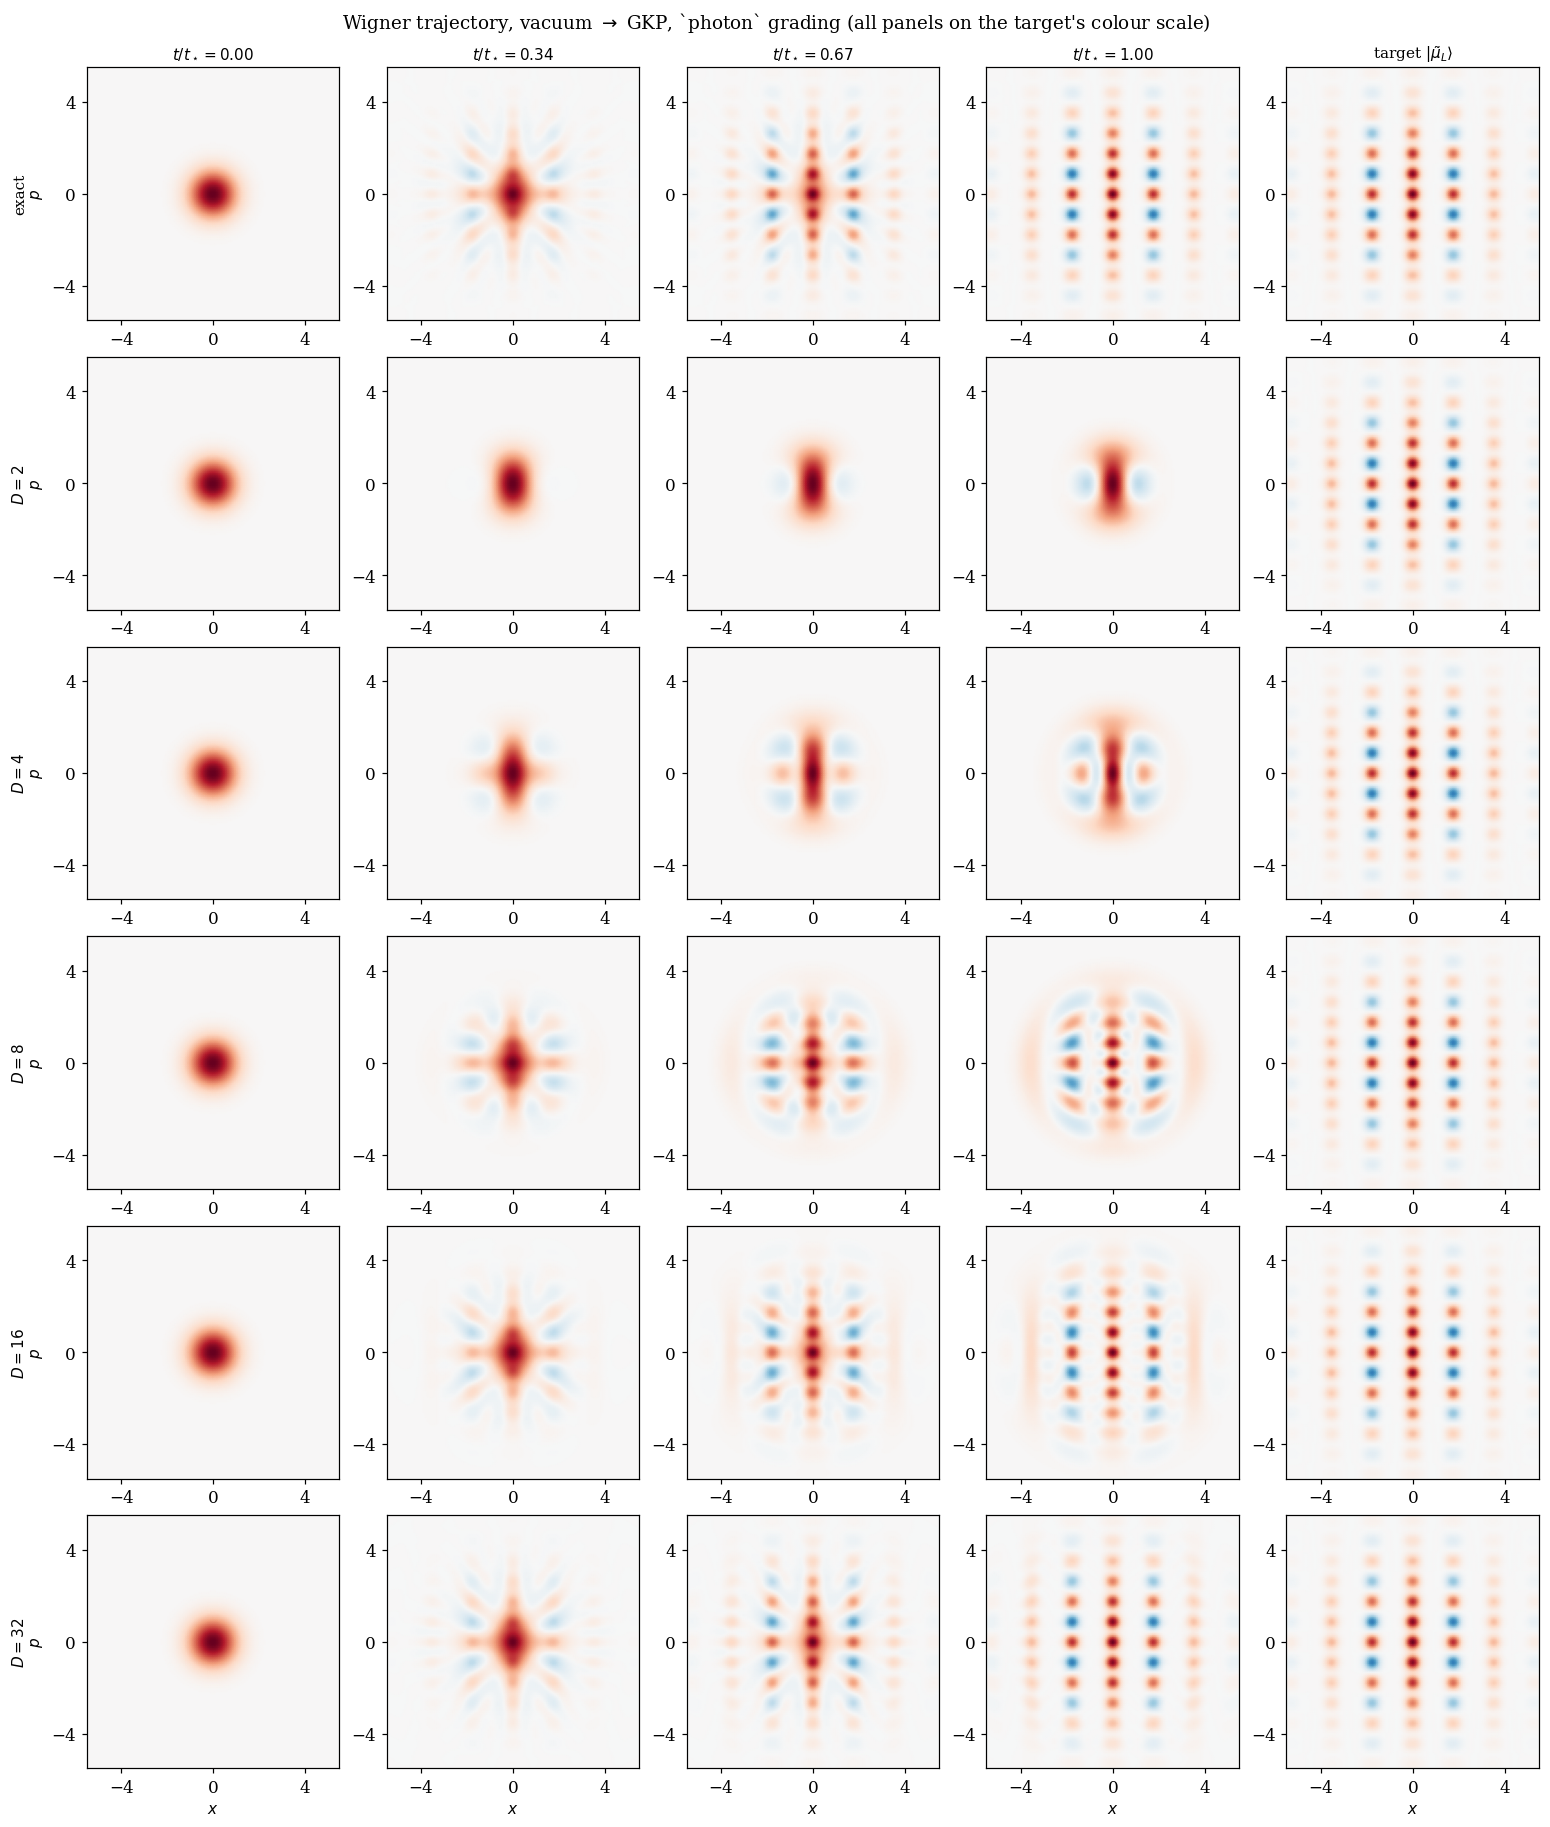

In [22]:
frac = np.array([0.0, 0.34, 0.67, 1.0])
panels = [("exact", H_EXACT)] + [(f"$D={D}$", graded_H(S_MOM, NRM, REF, DIM, D, "photon"))
                                 for D in (2, 4, 8, 16, 32)]
xw = pw = np.linspace(-5.5, 5.5, 141)

fig, axes = plt.subplots(len(panels), len(frac) + 1, figsize=(14.0, 2.75 * len(panels)),
                         constrained_layout=True)
W_tgt = wigner_numpy(PSI_F, xw, pw)
vmax = float(np.abs(W_tgt).max())
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

for row, (label, H) in enumerate(panels):
    tp = peak_fidelity_numeric(H, PSI_F, DIM)[1]
    psis = trajectory(H, frac * tp, DIM)
    for col, f in enumerate(frac):
        ax = axes[row, col]
        ax.pcolormesh(xw, pw, wigner_numpy(psis[col], xw, pw), cmap="RdBu_r",
                      norm=norm, shading="gouraud", rasterized=True)
        ax.set_aspect("equal"); ax.set_xticks([-4, 0, 4]); ax.set_yticks([-4, 0, 4])
        ax.grid(False)
        if row == 0:
            ax.set_title(rf"$t/t_\star={f:.2f}$", fontsize=10)
        if col == 0:
            ax.set_ylabel(label + "\n$p$", fontsize=10)
    ax = axes[row, -1]
    ax.pcolormesh(xw, pw, W_tgt, cmap="RdBu_r", norm=norm, shading="gouraud", rasterized=True)
    ax.set_aspect("equal"); ax.set_xticks([-4, 0, 4]); ax.set_yticks([-4, 0, 4]); ax.grid(False)
    if row == 0:
        ax.set_title(r"target $|\tilde\mu_L\rangle$", fontsize=10)
for col in range(len(frac) + 1):
    axes[-1, col].set_xlabel("$x$", fontsize=10)
fig.suptitle(r"Wigner trajectory, vacuum $\to$ GKP, `photon` grading "
             r"(all panels on the target's colour scale)", fontsize=12)
plt.show()

## 11. How many orders? $D_\star(\Delta)$

By §6 this is a property of the target state alone, so the sweep costs nothing: $D_\star(F_\star)$
is the Fock level at which the cumulative weight of $|\tilde\mu_L\rangle$ first exceeds $F_\star$.
The numeric column confirms the identity rather than discovering it.

Each row re-solves the lattice sum with its own `cutoff` and `dim`, since both must grow as
$\Delta$ shrinks (§2).

In [17]:
SWEEP = [(0.60, 3, 40), (0.50, 3, 50), (0.45, 4, 60),
         (0.40, 4, 80), (0.35, 5, 100), (0.30, 5, 120)]
THRESH = (0.9, 0.99, 0.999)

sweep_rows = []
for dl, cut, dim_s in SWEEP:
    S_s = lattice_moments(dim_s - 1, MU, ALPHA, BETA, dl, cut)
    psi_s, nrm_s = target_from_moments(dim_s, S_s)
    ref_s = reference_scalars(psi_s)
    cum = np.cumsum(np.abs(psi_s) ** 2)
    ds_an = [int(np.searchsorted(cum, th)) for th in THRESH]
    # Independent numeric check at the middle threshold: propagate and measure, no
    # closed form anywhere in this loop.
    d_num, f_num = None, float("nan")
    for D in range(2, dim_s, 2):
        H = graded_H(S_s, nrm_s, ref_s, dim_s, D, "photon")
        F_pk, _ = peak_fidelity_numeric(H, psi_s, dim_s, t_scale=ref_s["T_star"])
        if F_pk >= 0.99:
            d_num, f_num = D, F_pk
            break
    sweep_rows.append(dict(delta=dl, dB=-10 * np.log10(dl ** 2), dim=dim_s,
                           s=abs(ref_s["s"]), nbar=float(np.sum(np.arange(dim_s) * np.abs(psi_s) ** 2)),
                           theta=ref_s["theta_B"], Ds=ds_an, d_num=d_num, f_num=f_num,
                           w=w_of_D(S_s, nrm_s, ref_s, d_num or dim_s - 1)))

print(f"{'Delta':>6s} {'dB':>5s} {'|s|':>7s} {'nbar':>6s} {'theta_B':>8s} "
      f"{'D*(0.9)':>8s} {'D*(0.99)':>9s} {'D*(0.999)':>10s} {'D* num':>7s} {'F at D*':>9s}")
for r in sweep_rows:
    print(f"{r['delta']:6.2f} {r['dB']:5.1f} {r['s']:7.4f} {r['nbar']:6.2f} {r['theta']:8.4f} "
          f"{r['Ds'][0]:8d} {r['Ds'][1]:9d} {r['Ds'][2]:10d} {str(r['d_num']):>7s} "
          f"{r['f_num']:9.6f}")
print("\nD*(0.99) analytic == D* numeric in every row: the Fock-tail identity of sec 6,")
print("confirmed by propagation rather than assumed.")

 Delta    dB     |s|   nbar  theta_B  D*(0.9)  D*(0.99)  D*(0.999)  D* num   F at D*
  0.60   4.4  0.9261   0.45   0.3869        2         8          8       8  0.999908
  0.50   6.0  0.8566   1.08   0.5421        4         8         12       8  0.998535
  0.45   6.9  0.8036   1.65   0.6375        8         8         16       8  0.994607
  0.40   8.0  0.7377   2.44   0.7412        8        14         20      14  0.991840
  0.35   9.1  0.6607   3.52   0.8491        8        16         28      16  0.992872
  0.30  10.5  0.5761   5.05   0.9569        8        28         40      28  0.997945

D*(0.99) analytic == D* numeric in every row: the Fock-tail identity of sec 6,
confirmed by propagation rather than assumed.


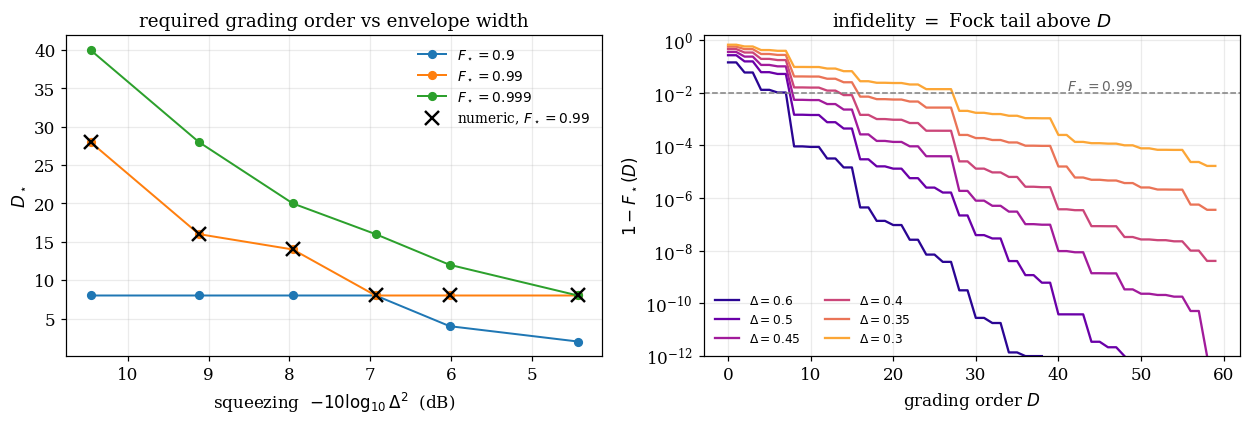

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
dB = np.array([r["dB"] for r in sweep_rows])
for i, th in enumerate(THRESH):
    axes[0].plot(dB, [r["Ds"][i] for r in sweep_rows], "o-", ms=5, lw=1.3,
                 label=rf"$F_\star={th}$")
axes[0].plot(dB, [r["d_num"] for r in sweep_rows], "kx", ms=9, mew=1.6,
             label=r"numeric, $F_\star=0.99$")
axes[0].set(xlabel="squeezing  $-10\\log_{10}\\Delta^2$  (dB)", ylabel=r"$D_\star$",
            title=r"required grading order vs envelope width")
axes[0].legend(fontsize=9)
axes[0].invert_xaxis()

# infidelity vs D at each Delta: the Fock tail, per sec 6
for (dl, cut, dim_s), c in zip(SWEEP, plt.cm.plasma(np.linspace(0.05, 0.8, len(SWEEP)))):
    S_s = lattice_moments(dim_s - 1, MU, ALPHA, BETA, dl, cut)
    psi_s, _ = target_from_moments(dim_s, S_s)
    Dg = np.arange(0, min(dim_s - 1, 60))
    tail = np.array([np.sum(np.abs(psi_s[D + 1:]) ** 2) for D in Dg])
    axes[1].semilogy(Dg, np.maximum(tail, 1e-12), color=c, lw=1.5,
                     label=rf"$\Delta={dl}$")
axes[1].axhline(0.01, color="0.5", ls="--", lw=1.0)
axes[1].text(41, 0.013, r"$F_\star=0.99$", fontsize=9, color="0.4")
axes[1].set(xlabel="grading order $D$", ylabel=r"$1-F_\star(D)$",
            title=r"infidelity $=$ Fock tail above $D$", ylim=(1e-12, 1.5))
axes[1].legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## 12. Reading, and where it plugs in

**The graded expansion is a structural statement, not an approximation scheme.** The $d$-grading
tells you which wave-mixing processes appear in $H_{\rm opt}$ — and §3 sharpens that to *even
orders only*, starting at two-photon squeezing — but there is no small parameter. The infidelity of
the order-$D$ generator is the target's Fock tail above $D$ (§6), and GKP tails are heavy: $D_\star=28$
at 10.5 dB. Treat `sigma_x_eff_expansion.tex` as a catalogue of required processes, not as a series
to truncate.

**The non-polynomial ingredient is the projector, and it is not optional.** $|0\rangle\langle0|$ is
what makes $H_{\rm opt}$ rank 2 and confines the trajectory to a plane. Drop it (`bare`) or truncate
it (`degree`) and you get an operator with super-factorially large spurious matrix elements, no
$\dim_{\rm F}\to\infty$ limit, and a trajectory that leaks immediately. This is the concrete reason
low-order wave mixing is the wrong synthesis target.

**So target the trajectory, not the generator.** The geodesic
$|\psi(t)\rangle=\cos\omega t\,|0\rangle+\sin\omega t\,e^{-i\phi}|\psi_f^\perp\rangle$ is closed-form and
cheap, which is exactly the setup your waypoint-retargeting workstream already assumes. Fitting ECD
or SNAP+displacement segments between waypoints on that curve is well posed; fitting them to
$H_{\rm opt}$ order by order is not.

**Two diagnostics worth promoting into the main pipeline.**
$\Delta E=\omega w_D$ (§9) is the right speed-limit observable — finite and monotone where
$\lVert H\rVert$ diverges — and gives the MT reference $T_{\rm MT}=\theta_B/\Delta E$ for the
Fubini–Study arc-length comparison on the roadmap. And the even-parity weight (§7) is a free
correctness check on any propagator or pulse sequence for square-lattice state prep: any odd-Fock
population is a bug, not physics.

**Suggested follow-ups.**

1. Lift `w_of_D`, `peak_fidelity_analytic` and the parity check into `brachistochrone.py` as
   `graded_generator(...)` and `mandelstam_tamm_reference(...)`; they are pure-NumPy-compatible and
   need no `Qarray` crossing.
2. Rerun §11 for the $|0_L\rangle\to|1_L\rangle$ transfer, where $s=\langle0_L|1_L\rangle$ is tiny and
   $\theta_B\to\pi/2$ — the $S_\Sigma$ machinery of the notes' §2.2 replaces the simple $S_0$ here.
3. The same grading applied to the *binomial* code, whose Fock support is finite by construction,
   should terminate exactly at $D=$ (max Fock level). That would be a clean positive control for
   this whole framework.